In [130]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [131]:
POINTS = set() # Tuple of (bins, pulls) points

LOWBINS = 30
HIGHBINS = 1468
LOWPULLS = 4
HIGHPULLS = 180

pull_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 16, 18, 20, 22, 25, 28, 31, 34, 38, 43, 48, 53, 60, 67, 74, 83, 93, 104, 116, 129, 145, 161, 180, 201, 225, 250]
bin_list = [8, 9, 10, 11, 12, 14, 16, 17, 19, 22, 24, 27, 30, 34, 38, 42, 47, 53, 59, 66, 74, 82, 92, 103, 115, 128, 143, 160, 179, 199, 223, 249, 278, 311, 347, 388, 434, 484, 541, 605, 676, 755, 843, 942, 1053, 1176, 1314, 1468, 1641, 1833, 2048]

for p in pull_list:
    for b in bin_list:
        POINTS.add((b, p))

POINTS = np.array(list(POINTS)) # Convert set to list
# print(POINTS)

In [132]:
# --- Define options for 1d plots --- #
PARAM_PULL = False # If False, x-axis is Number of nuisance parameters. If True, x-axis is number of bins.
CONST = HIGHBINS

if PARAM_PULL:
    POINTS = np.array(sorted(POINTS, key=lambda x: (x[0], x[1]))) # Sort by bins
else:
    POINTS = np.array(sorted(POINTS, key=lambda x: (x[1], x[0]))) # Sort by pulls

# print(POINTS)

In [133]:
# dict -> (nbinns, npulls) : [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

valid_process_times_points = np.array([(0,0)])
valid_fill_spectra_all_times_points = np.array([(0,0)])
valid_fill_spectra_phys_times_points = np.array([(0,0)])
valid_fill_spectra_nuis_times_points = np.array([(0,0)])
valid_chi2_no_grad_times_points = np.array([(0,0)])
valid_chi2_with_grad_times_points = np.array([(0,0)])

times_dict = {}
for bins, pulls in POINTS:
    process_time = -1
    fill_spectra_all_time = -1
    fill_spectra_phys_time = -1
    fill_spectra_nuis_time = -1
    chi2_no_grad_time = -1
    chi2_with_grad_time = -1

    with open(f'./scaling_outputs/scale_{bins}bins_{pulls}pulls_v3.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_all_time = time
            elif 'fillspectra_vary_phys' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_phys_time = time
            elif 'fillspectra_vary_nuis' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    fill_spectra_nuis_time = time
            elif 'metric_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    chi2_no_grad_time = time
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()[-1].split('=')[-1]
                try:
                    time = float(line_arr)
                finally:
                    chi2_with_grad_time = time
    f.close()
    '''
    with open(f'./time_logs/user_{bins}bins_{pulls}pulls_time.txt', 'r') as f2:
        line = f2.readline()
        try:
            time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
            process_time = time
        except:
            process_time = -1
    f2.close()
    '''
    times_dict[(bins, pulls)] = [process_time, fill_spectra_all_time, fill_spectra_phys_time, fill_spectra_nuis_time, chi2_no_grad_time, chi2_with_grad_time]

    if process_time != -1:
        valid_process_times_points = np.append(valid_process_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_all_time != -1:
        valid_fill_spectra_all_times_points = np.append(valid_fill_spectra_all_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_phys_time != -1:
        valid_fill_spectra_phys_times_points = np.append(valid_fill_spectra_phys_times_points, [(bins, pulls)], axis=0)
    if fill_spectra_nuis_time != -1:
        valid_fill_spectra_nuis_times_points = np.append(valid_fill_spectra_nuis_times_points, [(bins, pulls)], axis=0)
    if chi2_no_grad_time != -1:
        valid_chi2_no_grad_times_points = np.append(valid_chi2_no_grad_times_points, [(bins, pulls)], axis=0)
    if chi2_with_grad_time != -1:
        valid_chi2_with_grad_times_points = np.append(valid_chi2_with_grad_times_points, [(bins, pulls)], axis=0)
    
valid_process_times_points = valid_process_times_points[1:]
valid_fill_spectra_all_times_points = valid_fill_spectra_all_times_points[1:]
valid_fill_spectra_phys_times_points = valid_fill_spectra_phys_times_points[1:]
valid_fill_spectra_nuis_times_points = valid_fill_spectra_nuis_times_points[1:]
valid_chi2_no_grad_times_points = valid_chi2_no_grad_times_points[1:]
valid_chi2_with_grad_times_points = valid_chi2_with_grad_times_points[1:]

In [134]:
process_times = np.array([])
fill_spectra_all_times = np.array([])
fill_spectra_phys_times = np.array([])
fill_spectra_nuis_times = np.array([])
chi2_no_grad_times = np.array([])
chi2_with_grad_times = np.array([])

for bins, pulls in valid_process_times_points:
    process_times = np.append(process_times, times_dict[(bins, pulls)][0])

for bins, pulls in valid_fill_spectra_all_times_points:
    fill_spectra_all_times = np.append(fill_spectra_all_times, times_dict[(bins, pulls)][1])

for bins, pulls in valid_fill_spectra_phys_times_points:
    fill_spectra_phys_times = np.append(fill_spectra_phys_times, times_dict[(bins, pulls)][2])

for bins, pulls in valid_fill_spectra_nuis_times_points:
    fill_spectra_nuis_times = np.append(fill_spectra_nuis_times, times_dict[(bins, pulls)][3])

for bins, pulls in valid_chi2_no_grad_times_points:
    chi2_no_grad_times = np.append(chi2_no_grad_times, times_dict[(bins, pulls)][4])

for bins, pulls in valid_chi2_with_grad_times_points:
    chi2_with_grad_times = np.append(chi2_with_grad_times, times_dict[(bins, pulls)][5])

In [135]:
process_x0 = np.array([])
process_y0 = np.array([])
fs_all_x0 = np.array([])
fs_all_y0 = np.array([])
fs_phys_x0 = np.array([])
fs_phys_y0 = np.array([])
fs_nuis_x0 = np.array([])
fs_nuis_y0 = np.array([])
chi2_no_x0 = np.array([])
chi2_no_y0 = np.array([])
chi2_with_x0 = np.array([])
chi2_with_y0 = np.array([])

for bins, pulls in valid_process_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        process_x0 = np.append(process_x0, add)
        process_y0 = np.append(process_y0, times_dict[(bins, pulls)][0])

for bins, pulls in valid_fill_spectra_all_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_all_x0 = np.append(fs_all_x0, add)
        fs_all_y0 = np.append(fs_all_y0, times_dict[(bins, pulls)][1])

for bins, pulls in valid_fill_spectra_phys_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_phys_x0 = np.append(fs_phys_x0, add)
        fs_phys_y0 = np.append(fs_phys_y0, times_dict[(bins, pulls)][2])

for bins, pulls in valid_fill_spectra_nuis_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        fs_nuis_x0 = np.append(fs_nuis_x0, add)
        fs_nuis_y0 = np.append(fs_nuis_y0, times_dict[(bins, pulls)][3])

for bins, pulls in valid_chi2_no_grad_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        chi2_no_x0 = np.append(chi2_no_x0, add)
        chi2_no_y0 = np.append(chi2_no_y0, times_dict[(bins, pulls)][4])

for bins, pulls in valid_chi2_with_grad_times_points:
    if PARAM_PULL:
        var = pulls
        add = bins
    else:
        var = bins
        add = pulls
    if var == CONST:
        chi2_with_x0 = np.append(chi2_with_x0, add)
        chi2_with_y0 = np.append(chi2_with_y0, times_dict[(bins, pulls)][5])

In [136]:
def exponential_func(x, a, b):
    return a * np.exp(b * x)

def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

def linear_func(x, a, b):
    return a * x + b

params_exp, covar_exp = curve_fit(exponential_func, fs_all_x0, fs_all_y0, p0=(100, 0.006))
exp_residuals = fs_all_y0 - exponential_func(fs_all_x0, *params_exp)
exp_ss_res = np.sum(exp_residuals**2)
exp_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
exp_r_squared = 1 - (exp_ss_res / exp_ss_tot)

params_quad, covar_quad = curve_fit(quadratic_func, fs_all_x0, fs_all_y0)
quad_residuals = fs_all_y0 - quadratic_func(fs_all_x0, *params_quad)
quad_ss_res = np.sum(quad_residuals**2)
quad_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
quad_r_squared = 1 - (quad_ss_res / quad_ss_tot)

params_lin, covar_lin = curve_fit(linear_func, fs_all_x0, fs_all_y0)
lin_residuals = fs_all_y0 - linear_func(fs_all_x0, *params_lin)
lin_ss_res = np.sum(lin_residuals**2)
lin_ss_tot = np.sum((fs_all_y0 - np.mean(fs_all_y0))**2)
lin_r_squared = 1 - (lin_ss_res / lin_ss_tot)

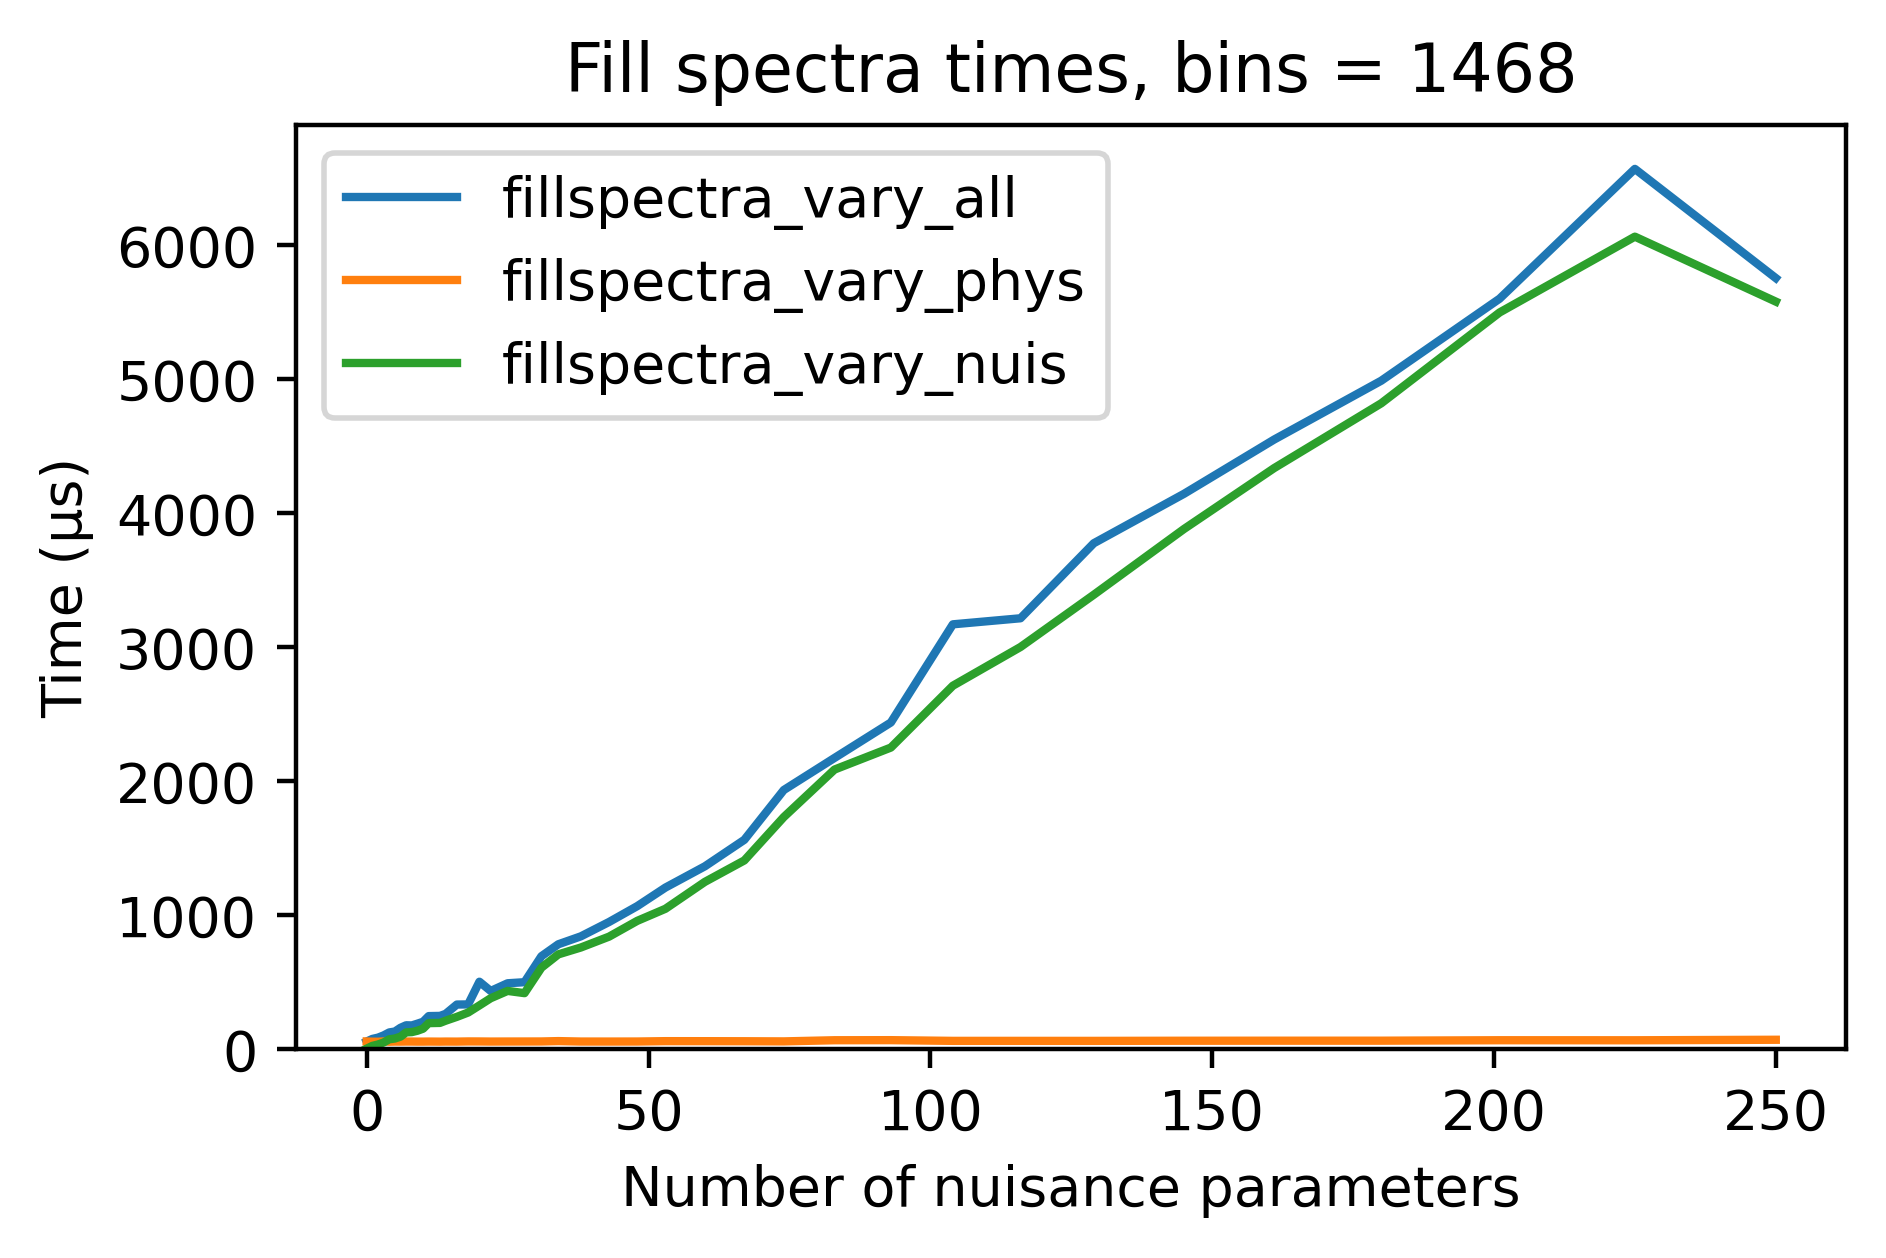

In [137]:
plt.figure(figsize=(5, 3), dpi=400)
plt.plot(fs_all_x0, fs_all_y0, label='fillspectra_vary_all')
plt.plot(fs_phys_x0, fs_phys_y0, label='fillspectra_vary_phys')
plt.plot(fs_nuis_x0, fs_nuis_y0, label='fillspectra_vary_nuis')
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('Fill spectra times, nuisance parameters = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('Fill spectra times, bins = ' + str(CONST))
plt.ylabel('Time (μs)')
plt.ylim(0,)
#plt.xscale('log')
plt.show()

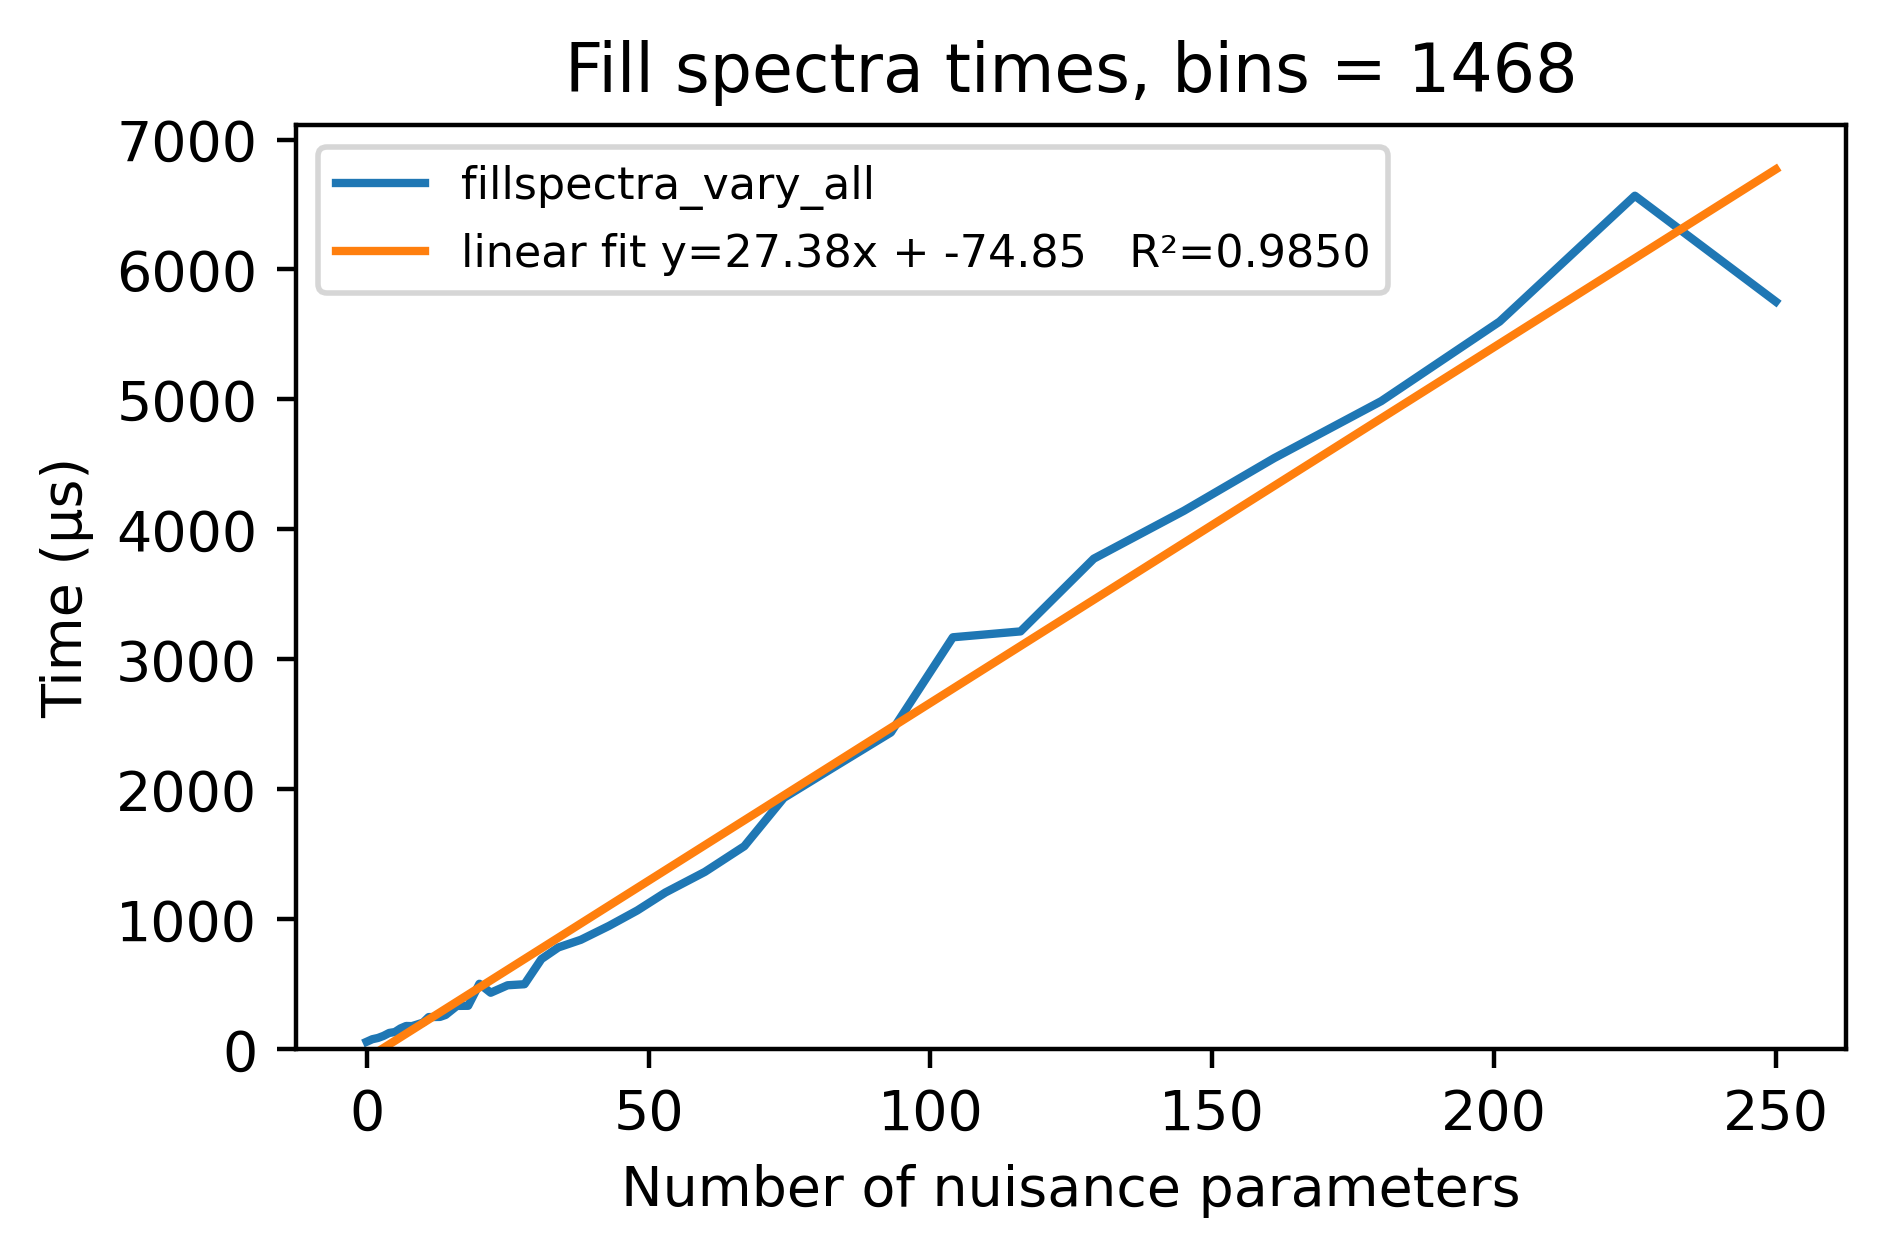

In [138]:
plt.figure(figsize=(5, 3), dpi=400)
plt.plot(fs_all_x0, fs_all_y0, label='fillspectra_vary_all')
#plt.plot(fs_all_x0, quadratic_func(fs_all_x0, *params_quad), label='quadratic fit y=%.3fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(params_quad), quad_r_squared))
#plt.plot(fs_all_x0, exponential_func(fs_all_x0, *params_exp), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(params_exp), exp_r_squared))
plt.plot(fs_all_x0, linear_func(fs_all_x0, *params_lin), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(params_lin), lin_r_squared))
plt.legend(fontsize=8)
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('Fill spectra times, nuisance parameters = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('Fill spectra times, bins = ' + str(CONST))
plt.ylabel('Time (μs)')
plt.ylim(0,)
#plt.xscale('log')
plt.show()

In [139]:
chi_quad_params, chi_covar_quad = curve_fit(quadratic_func, chi2_with_x0, chi2_with_y0)
chi_quad_residuals = chi2_with_y0 - quadratic_func(chi2_with_x0, *chi_quad_params)
chi_quad_ss_res = np.sum(chi_quad_residuals**2)
chi_quad_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_quad_r_squared = 1 - (chi_quad_ss_res / chi_quad_ss_tot)

chi_lin_params, chi_covar_lin = curve_fit(linear_func, chi2_with_x0, chi2_with_y0)
chi_lin_residuals = chi2_with_y0 - linear_func(chi2_with_x0, *chi_lin_params)
chi_lin_ss_res = np.sum(chi_lin_residuals**2)
chi_lin_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_lin_r_squared = 1 - (chi_lin_ss_res / chi_lin_ss_tot)

chi_exp_params, chi_covar_exp = curve_fit(exponential_func, chi2_with_x0, chi2_with_y0, p0=(100, 0.006))
chi_exp_residuals = chi2_with_y0 - exponential_func(chi2_with_x0, *chi_exp_params)
chi_exp_ss_res = np.sum(chi_exp_residuals**2)
chi_exp_ss_tot = np.sum((chi2_with_y0 - np.mean(chi2_with_y0))**2)
chi_exp_r_squared = 1 - (chi_exp_ss_res / chi_exp_ss_tot)

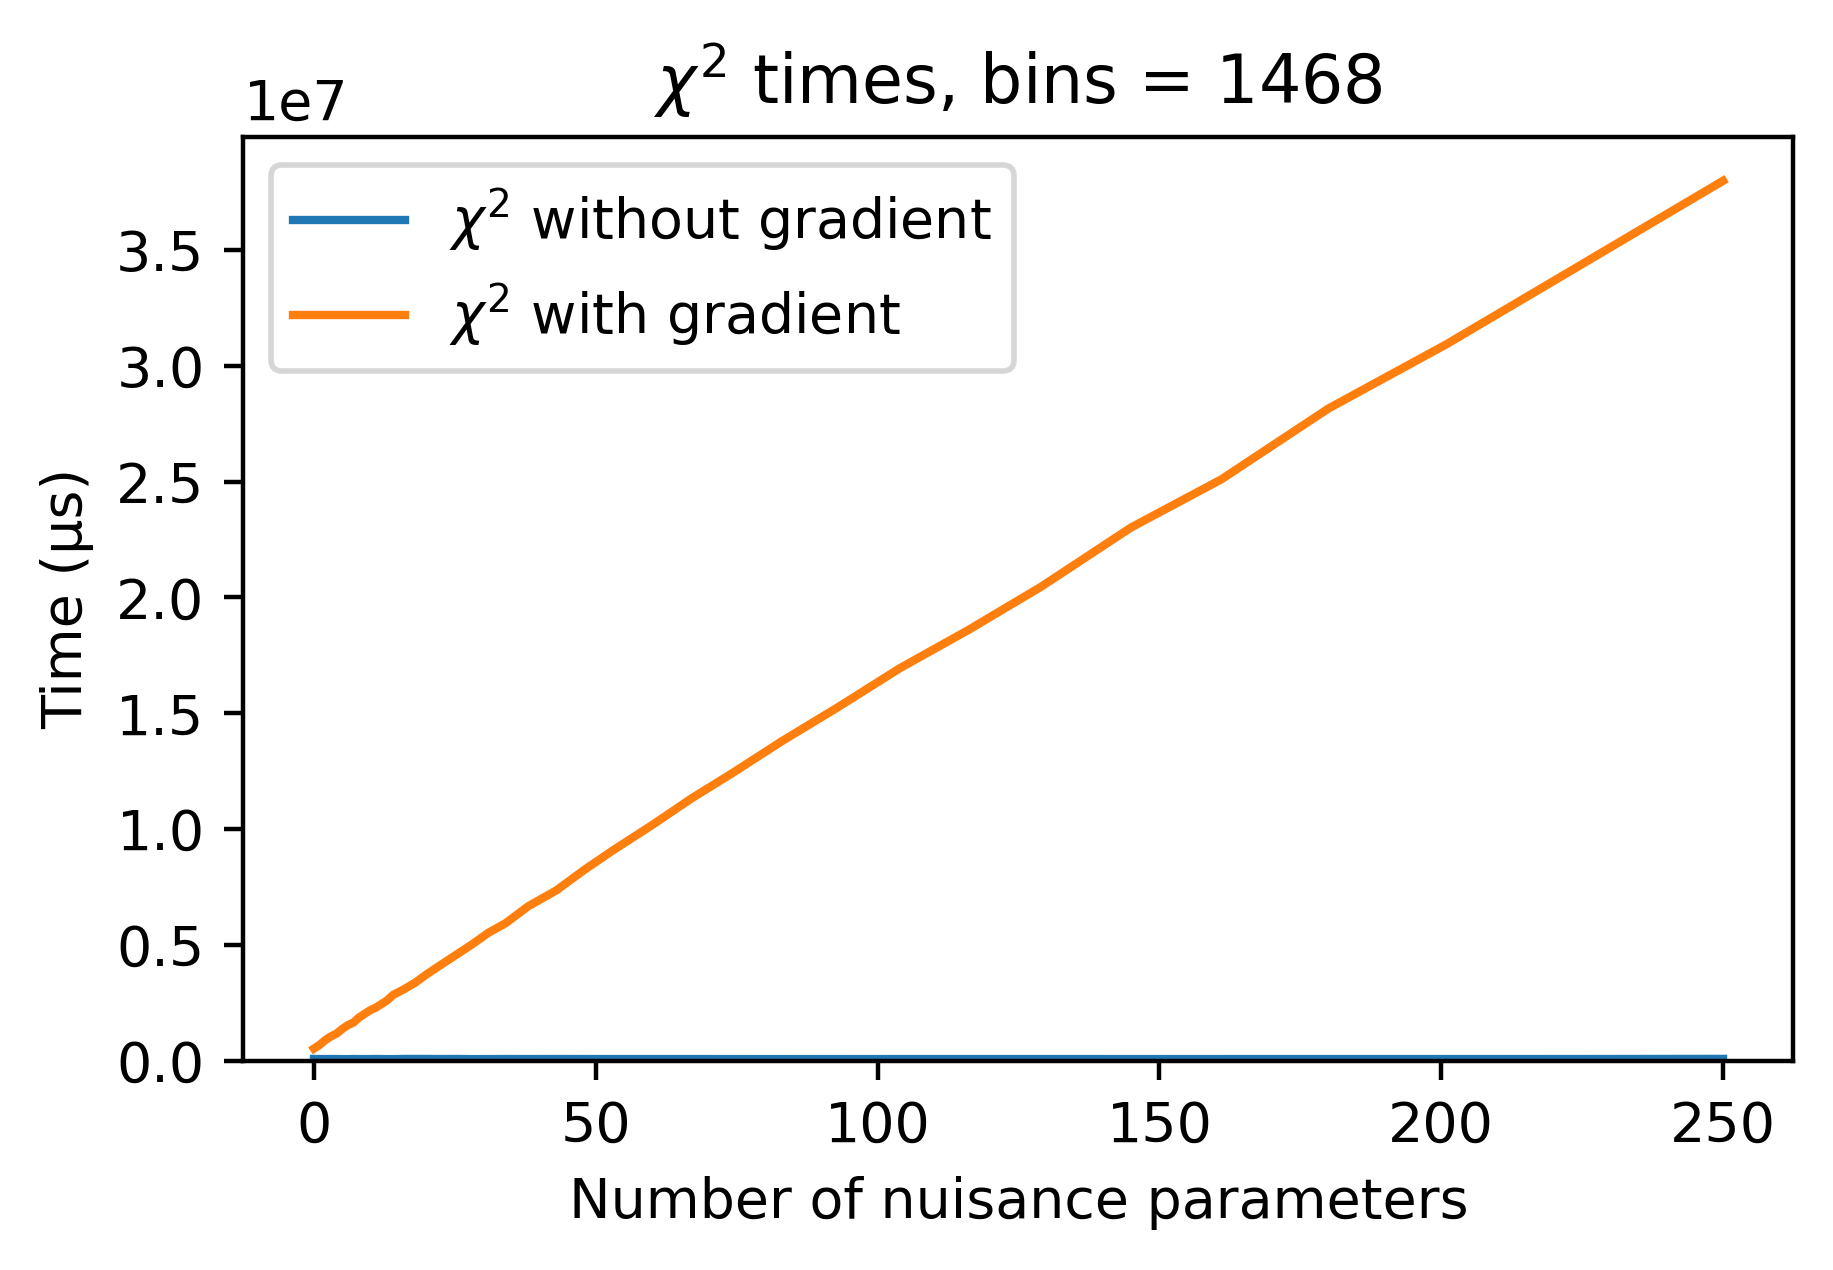

In [140]:
plt.figure(figsize=(5, 3), dpi=400)
plt.plot(chi2_no_x0, chi2_no_y0, label='$\\chi^2$ without gradient')
plt.plot(chi2_with_x0, chi2_with_y0, label='$\\chi^2$ with gradient')
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('$\\chi^2$ times, nuisance parameters = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('$\\chi^2$ times, bins = ' + str(CONST))
plt.ylabel('Time (μs)')
plt.ylim(0,)
#plt.xscale('log')
plt.show()

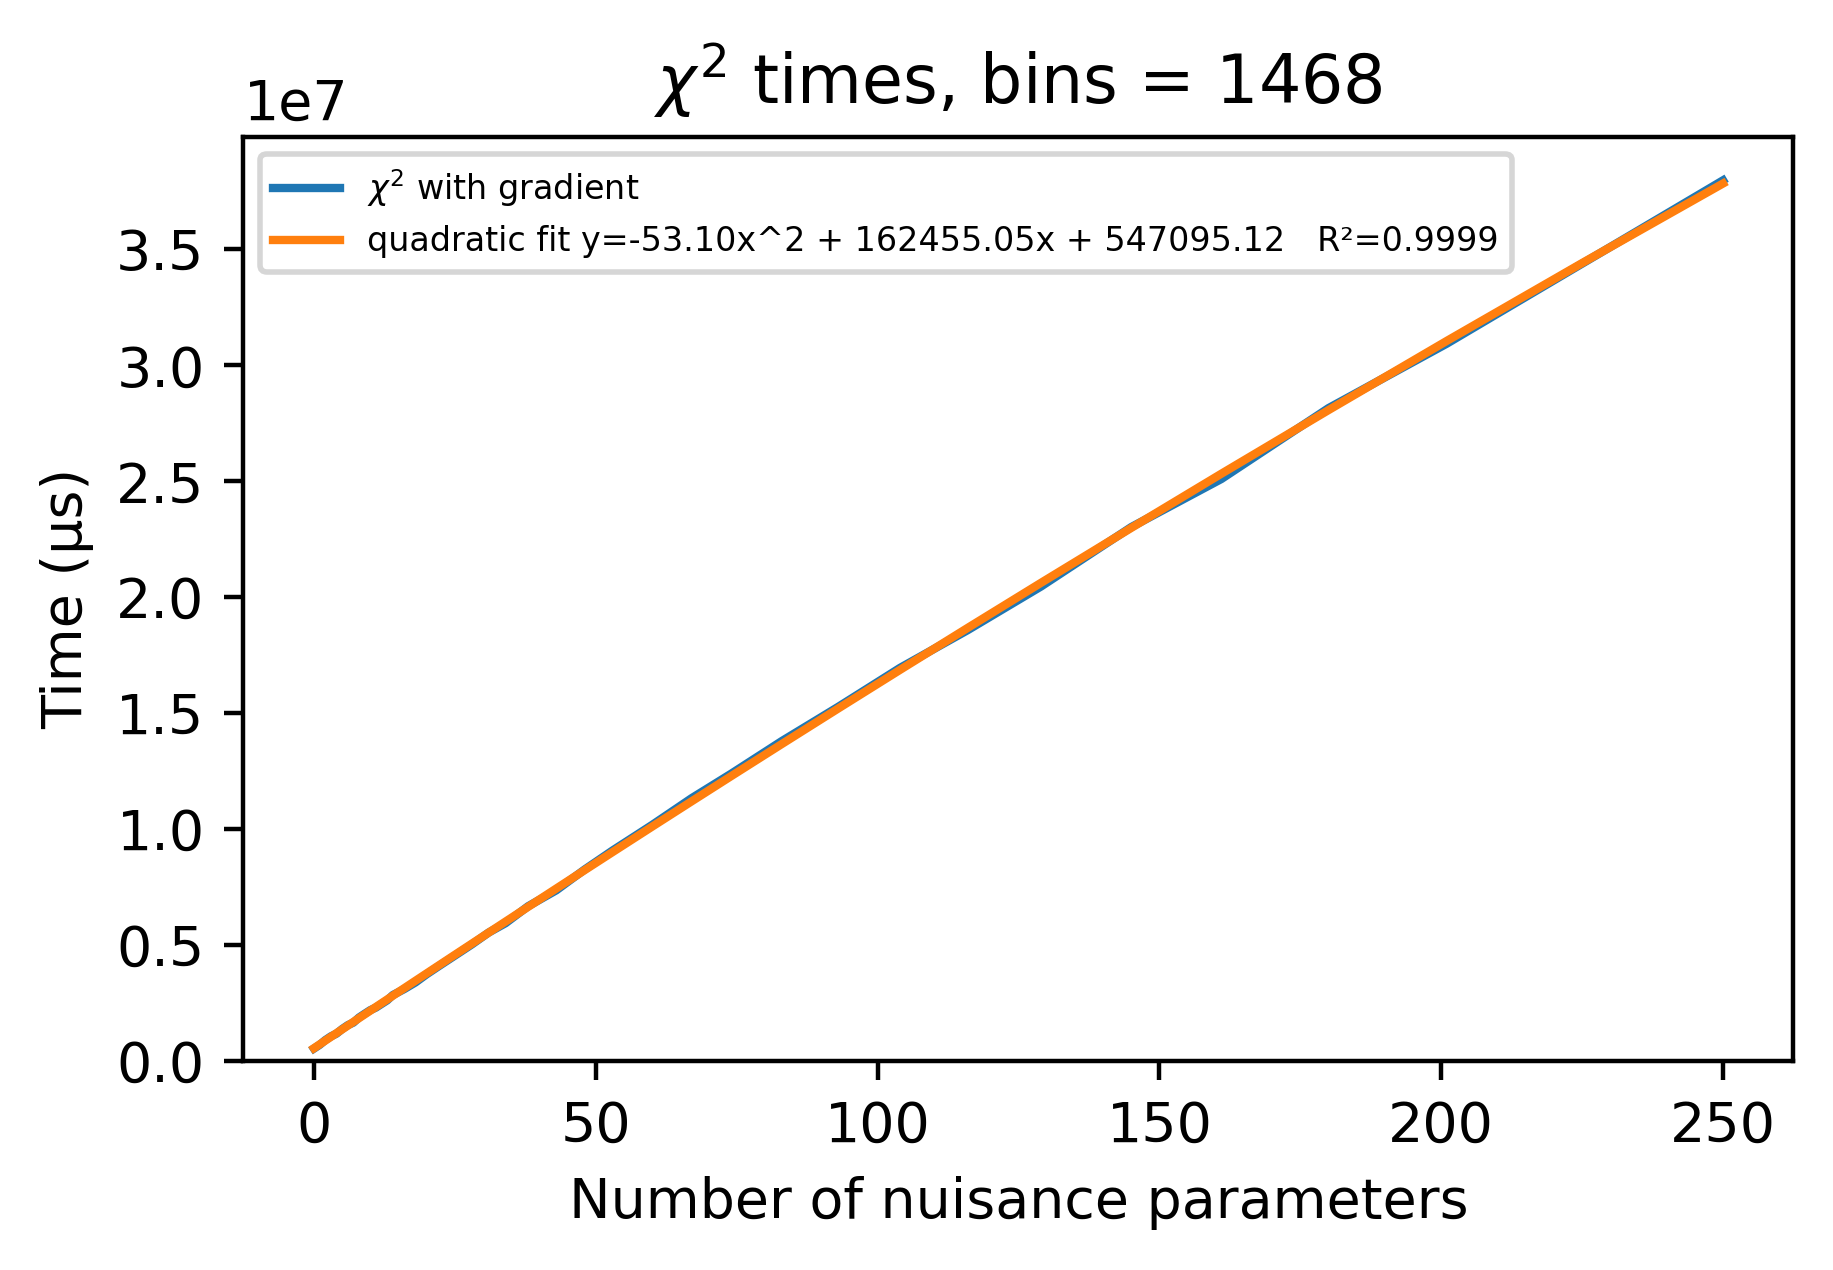

In [141]:
plt.figure(figsize=(5, 3), dpi=400)
plt.plot(chi2_with_x0, chi2_with_y0, label='$\\chi^2$ with gradient')
plt.plot(chi2_with_x0, quadratic_func(chi2_with_x0, *chi_quad_params), label='quadratic fit y=%.2fx^2 + %.2fx + %.2f   R²=%.4f' % (*tuple(chi_quad_params), chi_quad_r_squared))
#plt.plot(chi2_with_x0, exponential_func(chi2_with_x0, *chi_exp_params), label='exponential fit y=%.2fe^(%.4fx)        R²=%.4f' % (*tuple(chi_exp_params), chi_exp_r_squared))
#plt.plot(chi2_with_x0, linear_func(chi2_with_x0, *chi_lin_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(chi_lin_params), chi_lin_r_squared))
plt.legend(fontsize=6)
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('$\\chi^2$ times, nuisance parameters = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('$\\chi^2$ times, bins = ' + str(CONST))
plt.ylabel('Time (μs)')
plt.ylim(0,)
#plt.xscale('log')
plt.show()

In [142]:
'''def sqrt_func(x, a, b):
    return a * np.sqrt(x) + b

def log_func(x, a, b):
    return a * np.log(x) + b

sqrt_params, sqrt_covar = curve_fit(sqrt_func, process_x0, process_y0)
sqrt_residuals = process_y0 - sqrt_func(process_x0, *sqrt_params)
sqrt_ss_res = np.sum(sqrt_residuals**2)
sqrt_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
sqrt_r_squared = 1 - (sqrt_ss_res / sqrt_ss_tot)

log_params, log_covar = curve_fit(log_func, process_x0, process_y0)
log_residuals = process_y0 - log_func(process_x0, *log_params)
log_ss_res = np.sum(log_residuals**2)
log_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
log_r_squared = 1 - (log_ss_res / log_ss_tot)

lin_params, lin_covar = curve_fit(linear_func, process_x0, process_y0)
lin_residuals = process_y0 - linear_func(process_x0, *lin_params)
lin_ss_res = np.sum(lin_residuals**2)
lin_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)
lin_r_squared = 1 - (lin_ss_res / lin_ss_tot)'''

'def sqrt_func(x, a, b):\n    return a * np.sqrt(x) + b\n\ndef log_func(x, a, b):\n    return a * np.log(x) + b\n\nsqrt_params, sqrt_covar = curve_fit(sqrt_func, process_x0, process_y0)\nsqrt_residuals = process_y0 - sqrt_func(process_x0, *sqrt_params)\nsqrt_ss_res = np.sum(sqrt_residuals**2)\nsqrt_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)\nsqrt_r_squared = 1 - (sqrt_ss_res / sqrt_ss_tot)\n\nlog_params, log_covar = curve_fit(log_func, process_x0, process_y0)\nlog_residuals = process_y0 - log_func(process_x0, *log_params)\nlog_ss_res = np.sum(log_residuals**2)\nlog_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)\nlog_r_squared = 1 - (log_ss_res / log_ss_tot)\n\nlin_params, lin_covar = curve_fit(linear_func, process_x0, process_y0)\nlin_residuals = process_y0 - linear_func(process_x0, *lin_params)\nlin_ss_res = np.sum(lin_residuals**2)\nlin_ss_tot = np.sum((process_y0 - np.mean(process_y0))**2)\nlin_r_squared = 1 - (lin_ss_res / lin_ss_tot)'

In [143]:
'''plt.figure(figsize=(5, 3), dpi=400)
plt.plot(process_x0, process_y0)
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('Time to run process, Npulls = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('Time to run process, Nbins = ' + str(CONST))
plt.ylabel('Time (s)')
plt.ylim(0,)
plt.show()'''

"plt.figure(figsize=(5, 3), dpi=400)\nplt.plot(process_x0, process_y0)\nif PARAM_PULL:\n    plt.xlabel('Number of bins')\n    plt.title('Time to run process, Npulls = ' + str(CONST))\nelse:\n    plt.xlabel('Number of nuisance parameters')\n    plt.title('Time to run process, Nbins = ' + str(CONST))\nplt.ylabel('Time (s)')\nplt.ylim(0,)\nplt.show()"

In [144]:
'''plt.figure(figsize=(5, 3), dpi=400)
plt.plot(process_x0, process_y0, label='process time')
plt.plot(process_x0, sqrt_func(process_x0, *sqrt_params), label='sqrt fit y=%.2f*sqrt(x) + %.2f   R²=%.4f' % (*tuple(sqrt_params), sqrt_r_squared))
plt.plot(process_x0, log_func(process_x0, *log_params), label='log fit y=%.2f*log(x) + %.2f   R²=%.4f' % (*tuple(log_params), log_r_squared))
plt.plot(process_x0, linear_func(process_x0, *lin_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(lin_params), lin_r_squared))
plt.legend()
if PARAM_PULL:
    plt.xlabel('Number of bins')
    plt.title('Time to run process, Npulls = ' + str(CONST))
else:
    plt.xlabel('Number of nuisance parameters')
    plt.title('Time to run process, Nbins = ' + str(CONST))
plt.ylabel('Time (s)')
plt.ylim(0,)
plt.show()'''

"plt.figure(figsize=(5, 3), dpi=400)\nplt.plot(process_x0, process_y0, label='process time')\nplt.plot(process_x0, sqrt_func(process_x0, *sqrt_params), label='sqrt fit y=%.2f*sqrt(x) + %.2f   R²=%.4f' % (*tuple(sqrt_params), sqrt_r_squared))\nplt.plot(process_x0, log_func(process_x0, *log_params), label='log fit y=%.2f*log(x) + %.2f   R²=%.4f' % (*tuple(log_params), log_r_squared))\nplt.plot(process_x0, linear_func(process_x0, *lin_params), label='linear fit y=%.2fx + %.2f   R²=%.4f' % (*tuple(lin_params), lin_r_squared))\nplt.legend()\nif PARAM_PULL:\n    plt.xlabel('Number of bins')\n    plt.title('Time to run process, Npulls = ' + str(CONST))\nelse:\n    plt.xlabel('Number of nuisance parameters')\n    plt.title('Time to run process, Nbins = ' + str(CONST))\nplt.ylabel('Time (s)')\nplt.ylim(0,)\nplt.show()"

In [145]:
'''plt.figure(figsize=(5, 3), dpi=400)
for bins, pulls in valid_process_times_points:
    plt.scatter(bins, pulls, c=times_dict[(bins, pulls)][0], cmap='viridis',marker='s', s=70, vmin=0, vmax=max(process_times))
plt.colorbar(label='Process time (s)')
plt.xlabel('Number of bins')
plt.ylabel('Number of nuisance parameters')
plt.title('Process times')
plt.axis('equal')
plt.xlim(0,1500)
plt.ylim(0,1000)
plt.show()'''

"plt.figure(figsize=(5, 3), dpi=400)\nfor bins, pulls in valid_process_times_points:\n    plt.scatter(bins, pulls, c=times_dict[(bins, pulls)][0], cmap='viridis',marker='s', s=70, vmin=0, vmax=max(process_times))\nplt.colorbar(label='Process time (s)')\nplt.xlabel('Number of bins')\nplt.ylabel('Number of nuisance parameters')\nplt.title('Process times')\nplt.axis('equal')\nplt.xlim(0,1500)\nplt.ylim(0,1000)\nplt.show()"

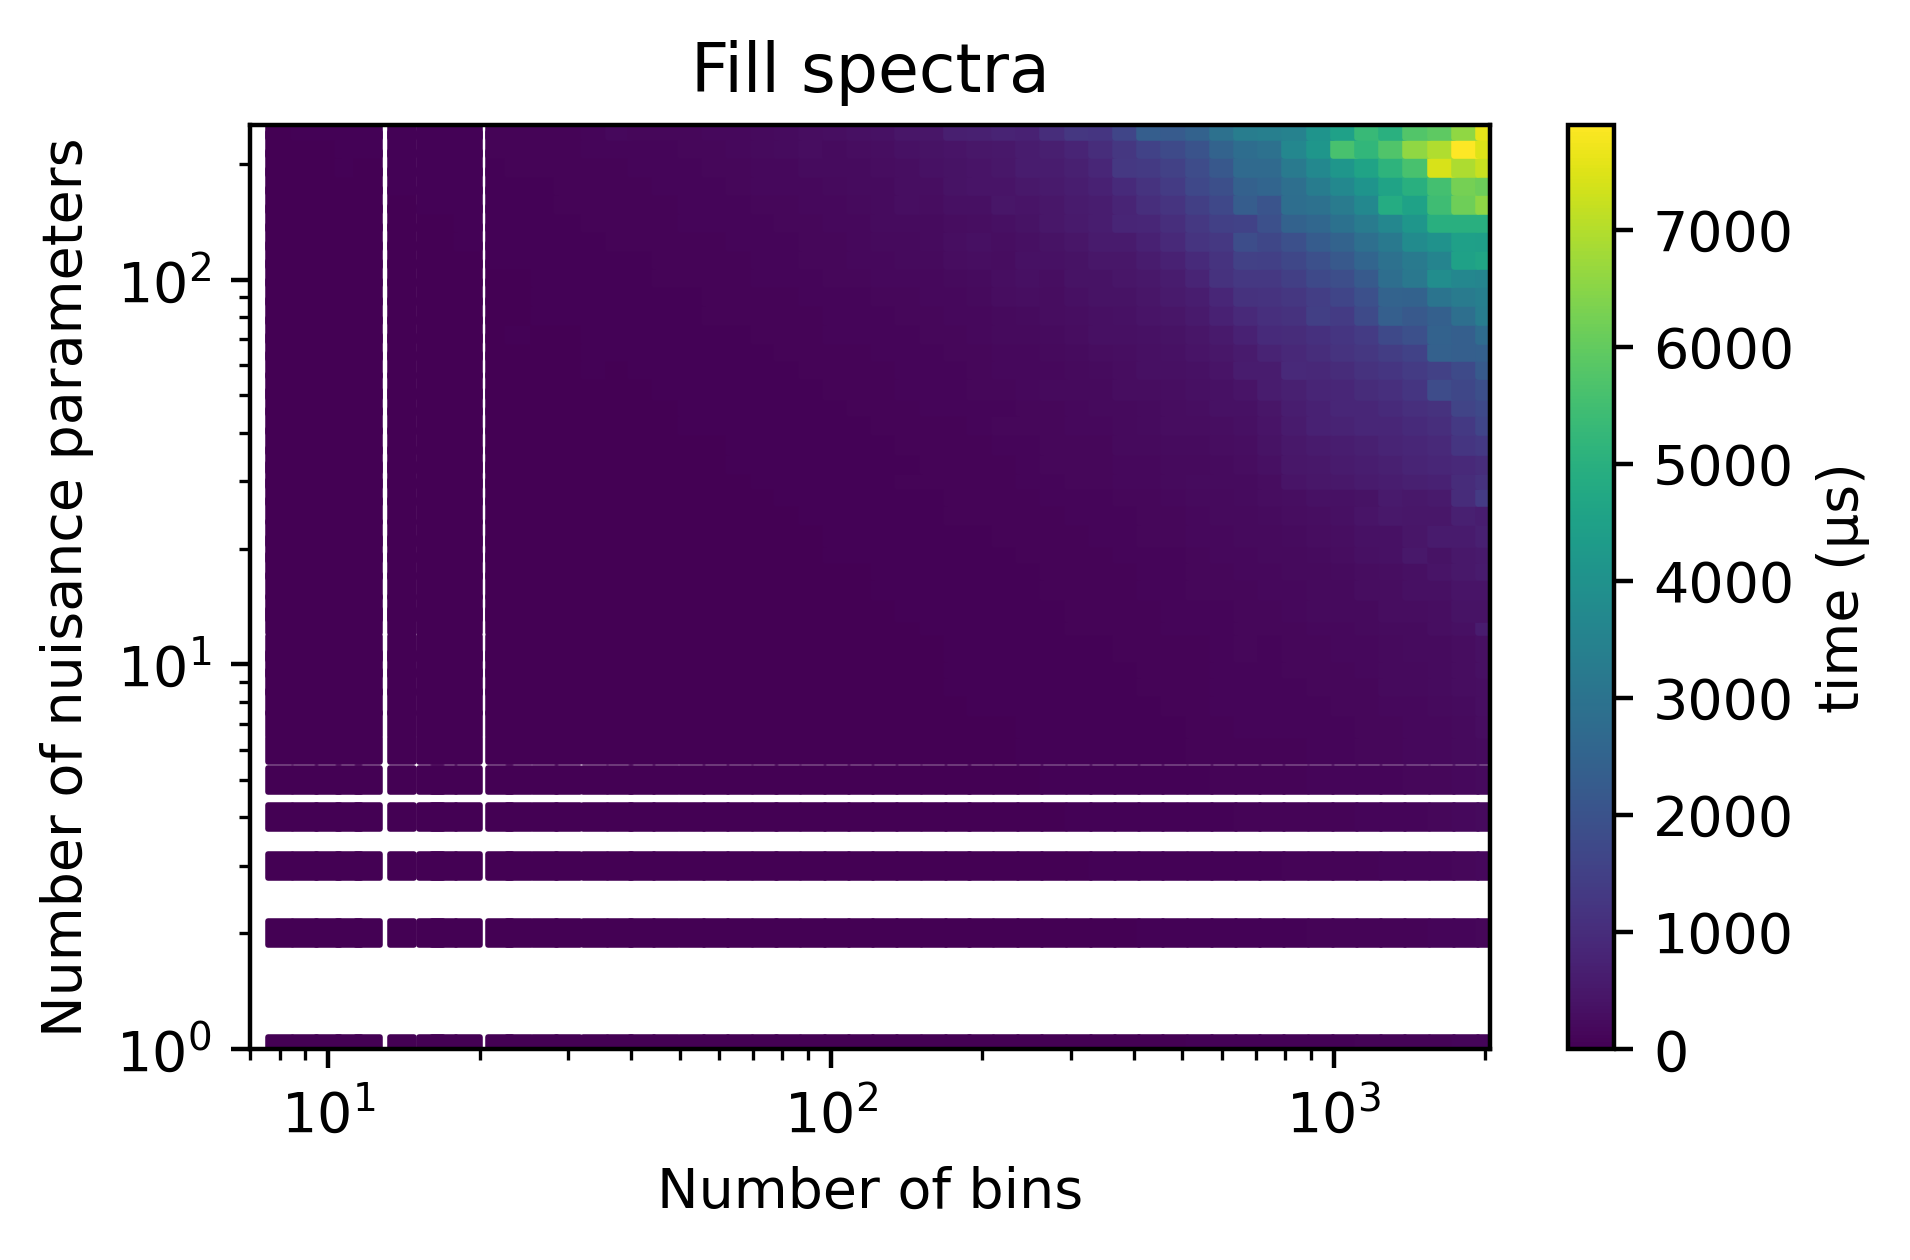

In [154]:
plt.figure(figsize=(5, 3), dpi=400)
for bins, pulls in valid_fill_spectra_all_times_points:
    plt.scatter(bins, pulls, c=times_dict[(bins, pulls)][1], cmap='viridis',marker='s', s=20, vmin=0, vmax=max(fill_spectra_all_times))
plt.colorbar(label='time (μs)')
plt.xlabel('Number of bins')
plt.ylabel('Number of nuisance parameters')
plt.title('Fill spectra')
plt.xlim(7,2050)
plt.xscale('log')
plt.ylim(1,252)
plt.yscale('log')
plt.show()

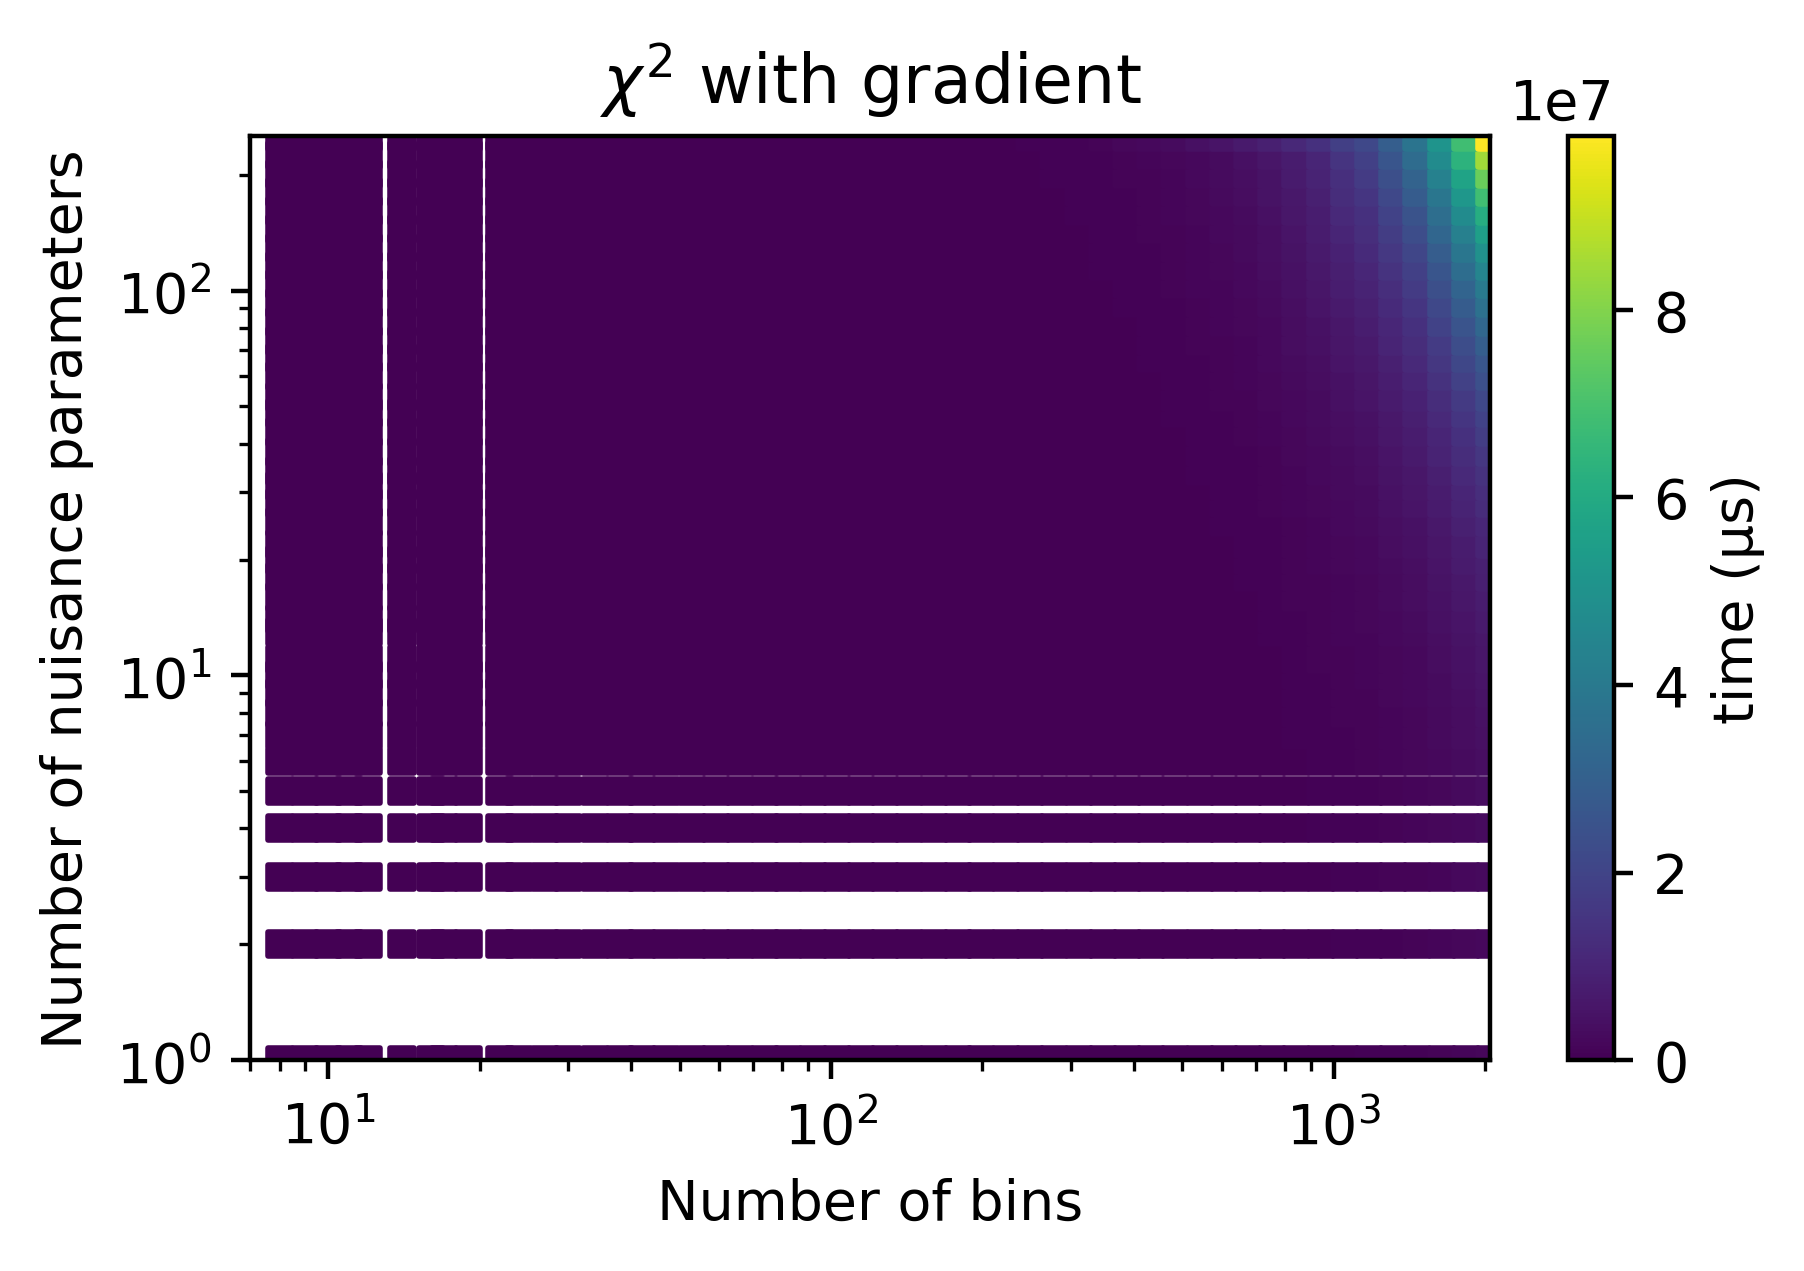

In [155]:
plt.figure(figsize=(5, 3), dpi=400)
for bins, pulls in valid_chi2_with_grad_times_points:
    plt.scatter(bins, pulls, c=times_dict[(bins, pulls)][5], cmap='viridis',marker='s', s=20, vmin=0, vmax=max(chi2_with_grad_times))
plt.colorbar(label='time (μs)')
plt.xlabel('Number of bins')
plt.ylabel('Number of nuisance parameters')
plt.title('$\\chi^2$ with gradient')
plt.xlim(7,2050)
plt.xscale('log')
plt.ylim(1,252)
plt.yscale('log')
plt.show()

In [148]:
# 20 norms vs 20 splines and 10 norms vs 10 splines to see if they take the same time to run with the same number of bins
# Also check if repeating the same name for splines could work

tags = np.array(['pulltest_10norm', 'pulltest_20norm', 'pulltest_10repeat_spline', 'pulltest_20repeat_spline', 'pulltest_10spline', 'pulltest_20spline'])

pulltest_process_times = np.array([])
pulltest_fill_spectra_times = np.array([])
pulltest_chi2_with_grad_times = np.array([])

for tag in tags:
    with open(f'./scaling_outputs/scale_{tag}.txt', 'r') as f:
        lines = f.readlines()
        for line in lines:
            if 'fillspectra_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_fill_spectra_times = np.append(pulltest_fill_spectra_times, time)
            elif 'metric_grad_vary_all' in line:
                line_arr = line.split()
                time = float(line_arr[-1].split('=')[-1])
                pulltest_chi2_with_grad_times = np.append(pulltest_chi2_with_grad_times, time)
    f.close()

    with open(f'./time_logs/user_{tag}_time.txt', 'r') as f2:
        line = f2.readline()
        time = float(line.split()[1].split('m')[0]) * 60 + float(line.split()[1].split('m')[1].split('s')[0])
        pulltest_process_times = np.append(pulltest_process_times, time)
    f2.close()

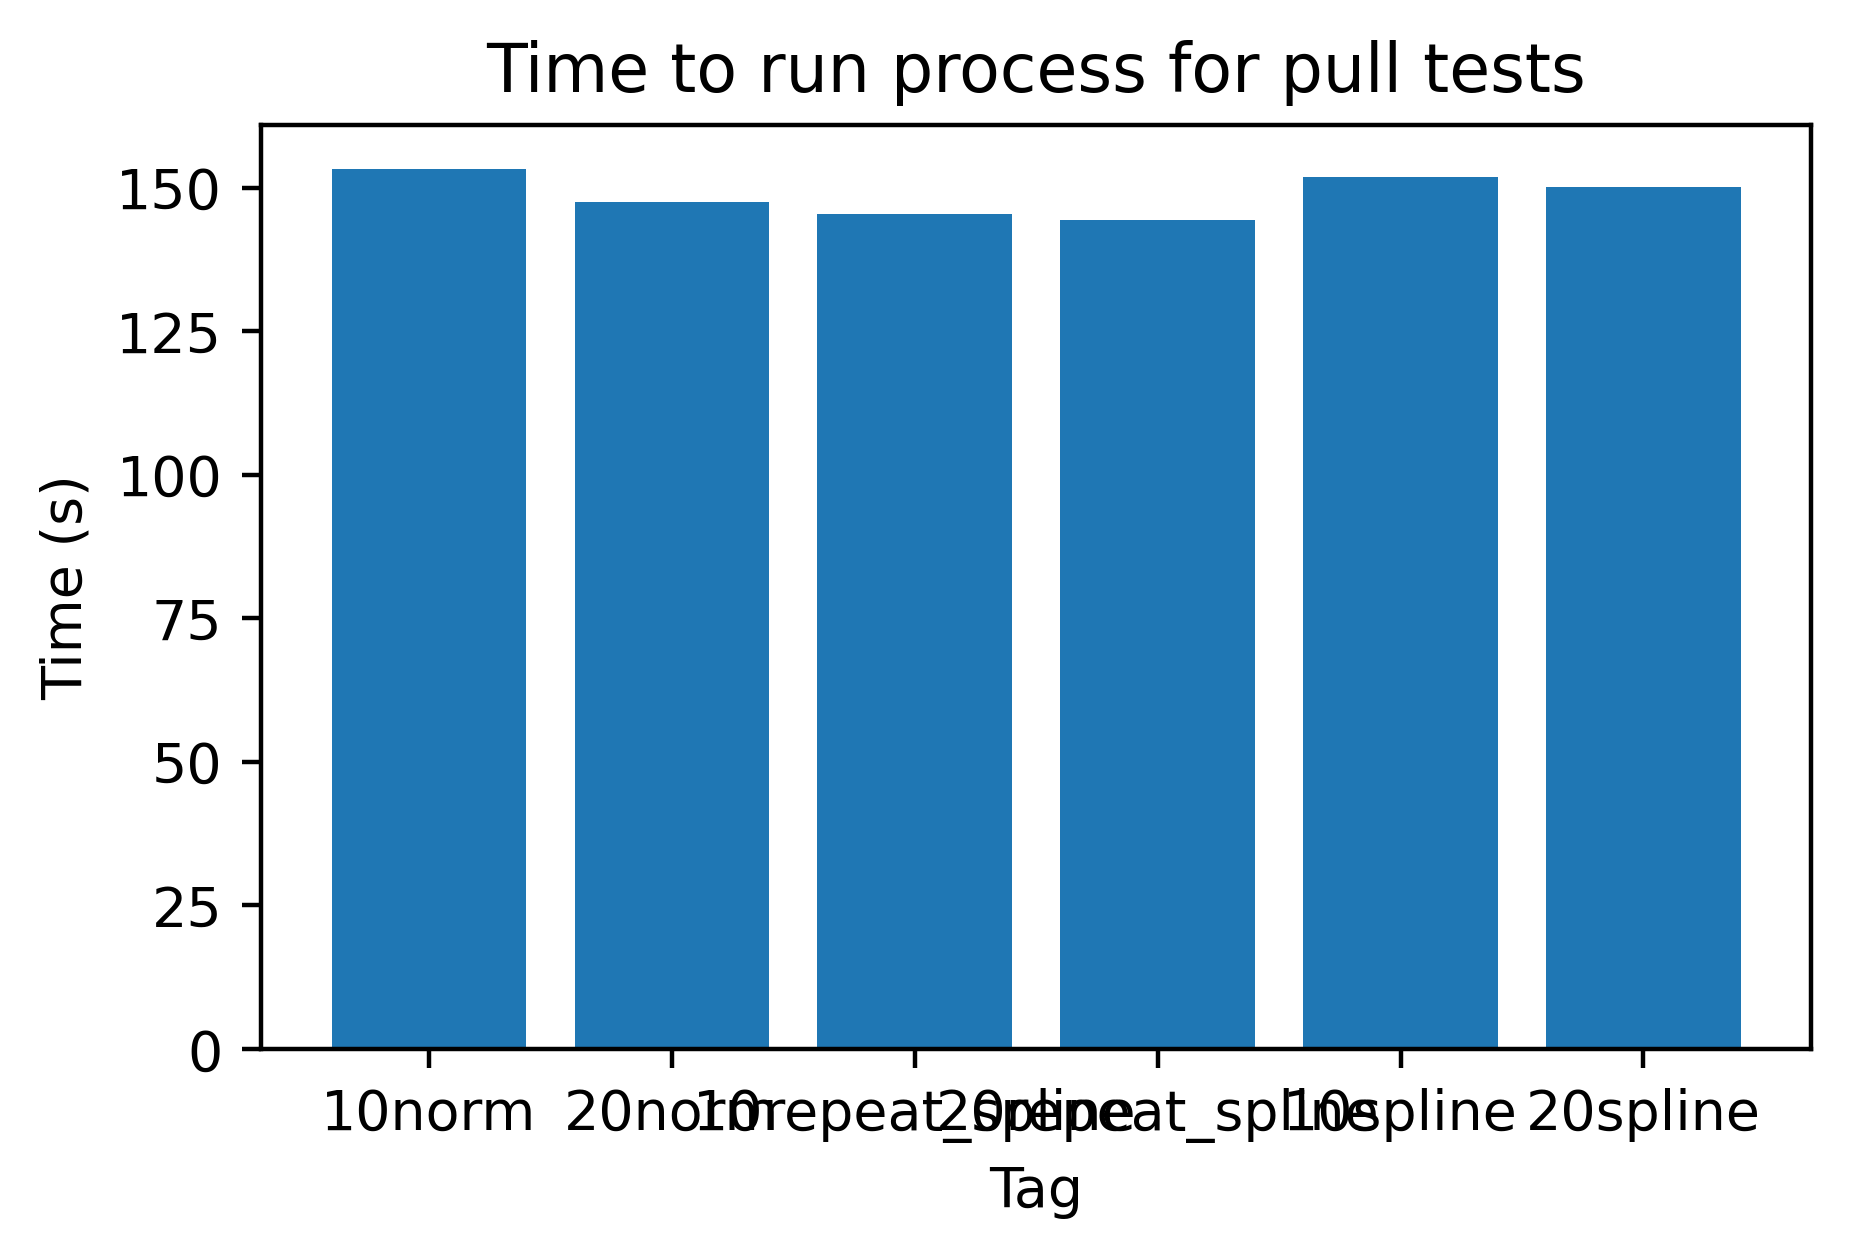

In [149]:
plt.figure(figsize=(5, 3), dpi=400)
plt.bar([t[9:] for t in tags], pulltest_process_times)
plt.xlabel('Tag')
plt.ylabel('Time (s)')
plt.title('Time to run process for pull tests')
plt.ylim(0,)
plt.show()

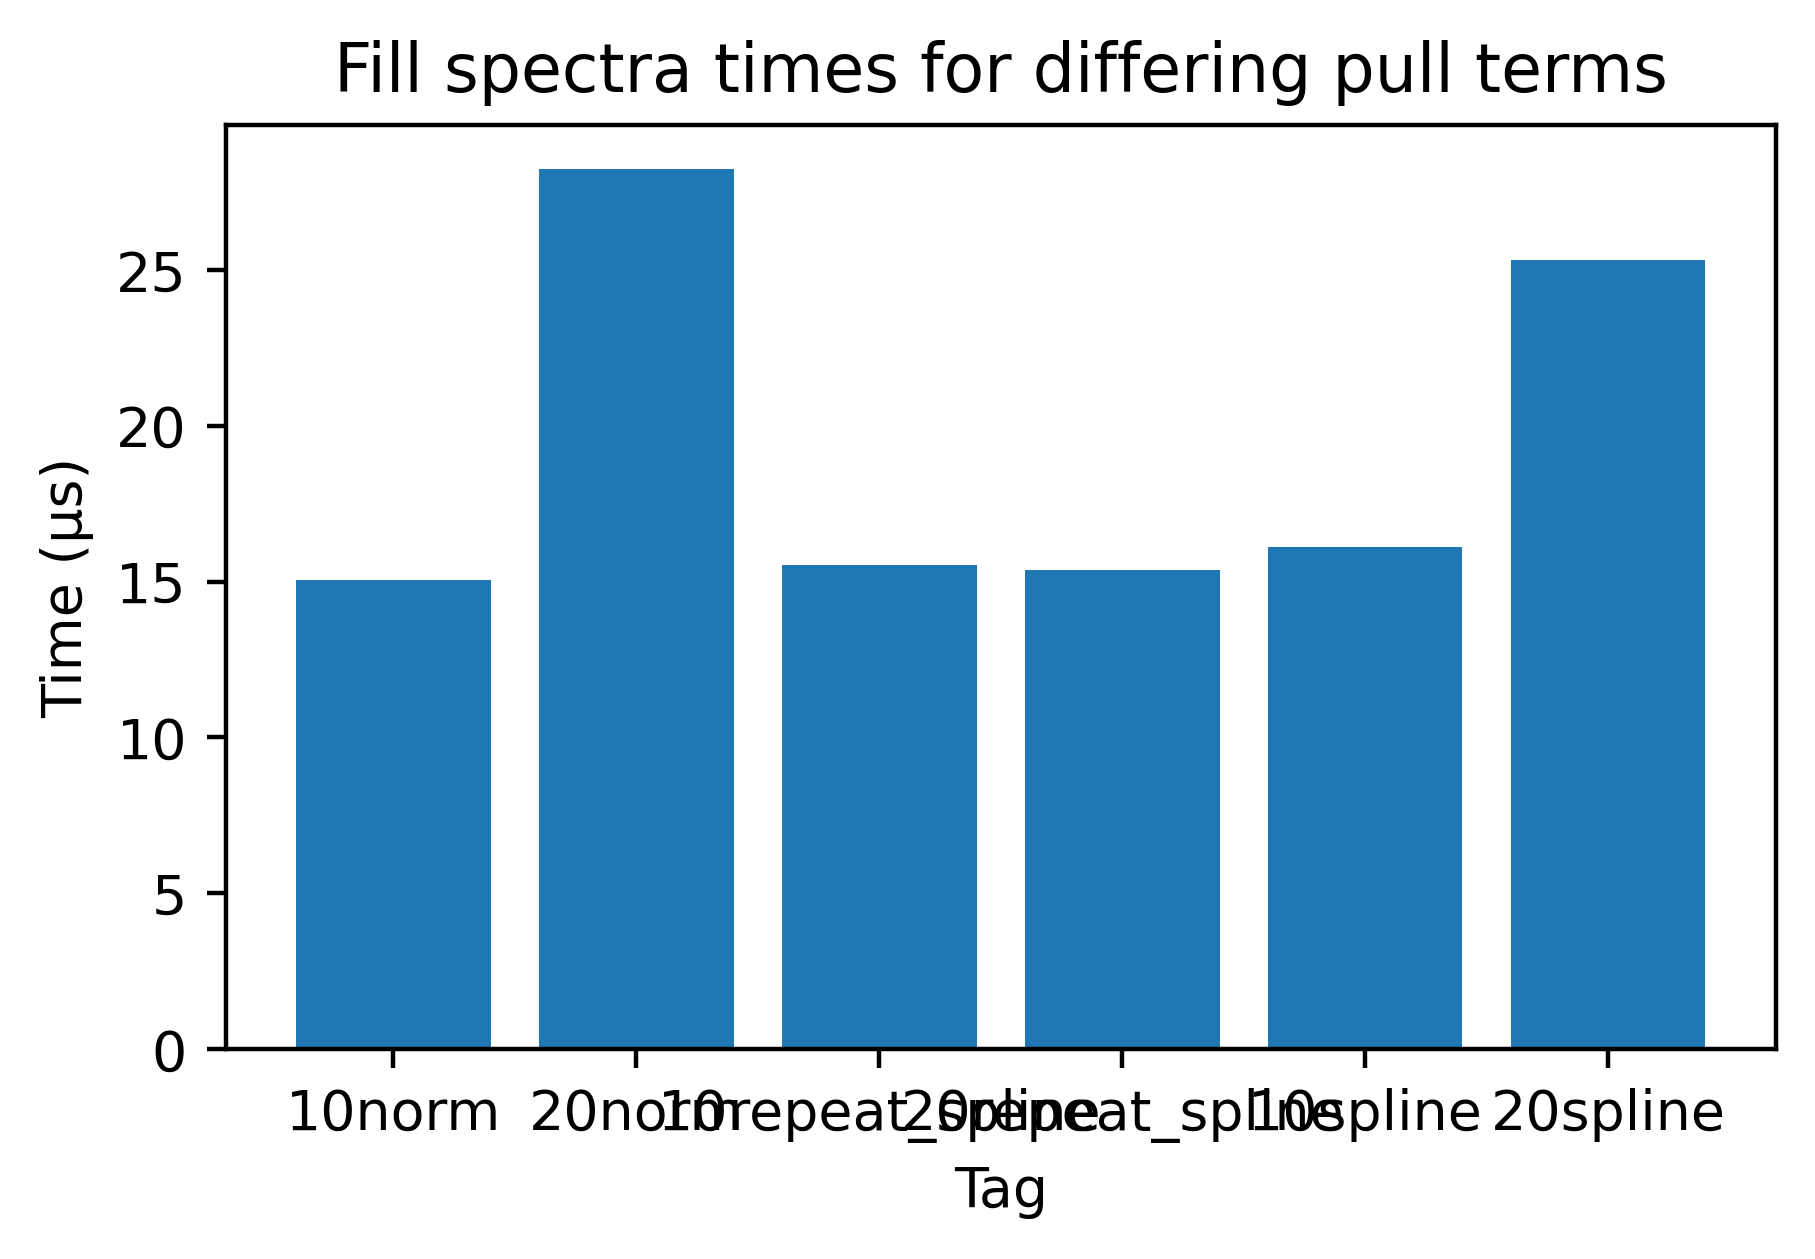

In [150]:
plt.figure(figsize=(5, 3), dpi=400)
plt.bar([t[9:] for t in tags], pulltest_fill_spectra_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Fill spectra times for differing pull terms')
plt.ylim(0,)
plt.show()

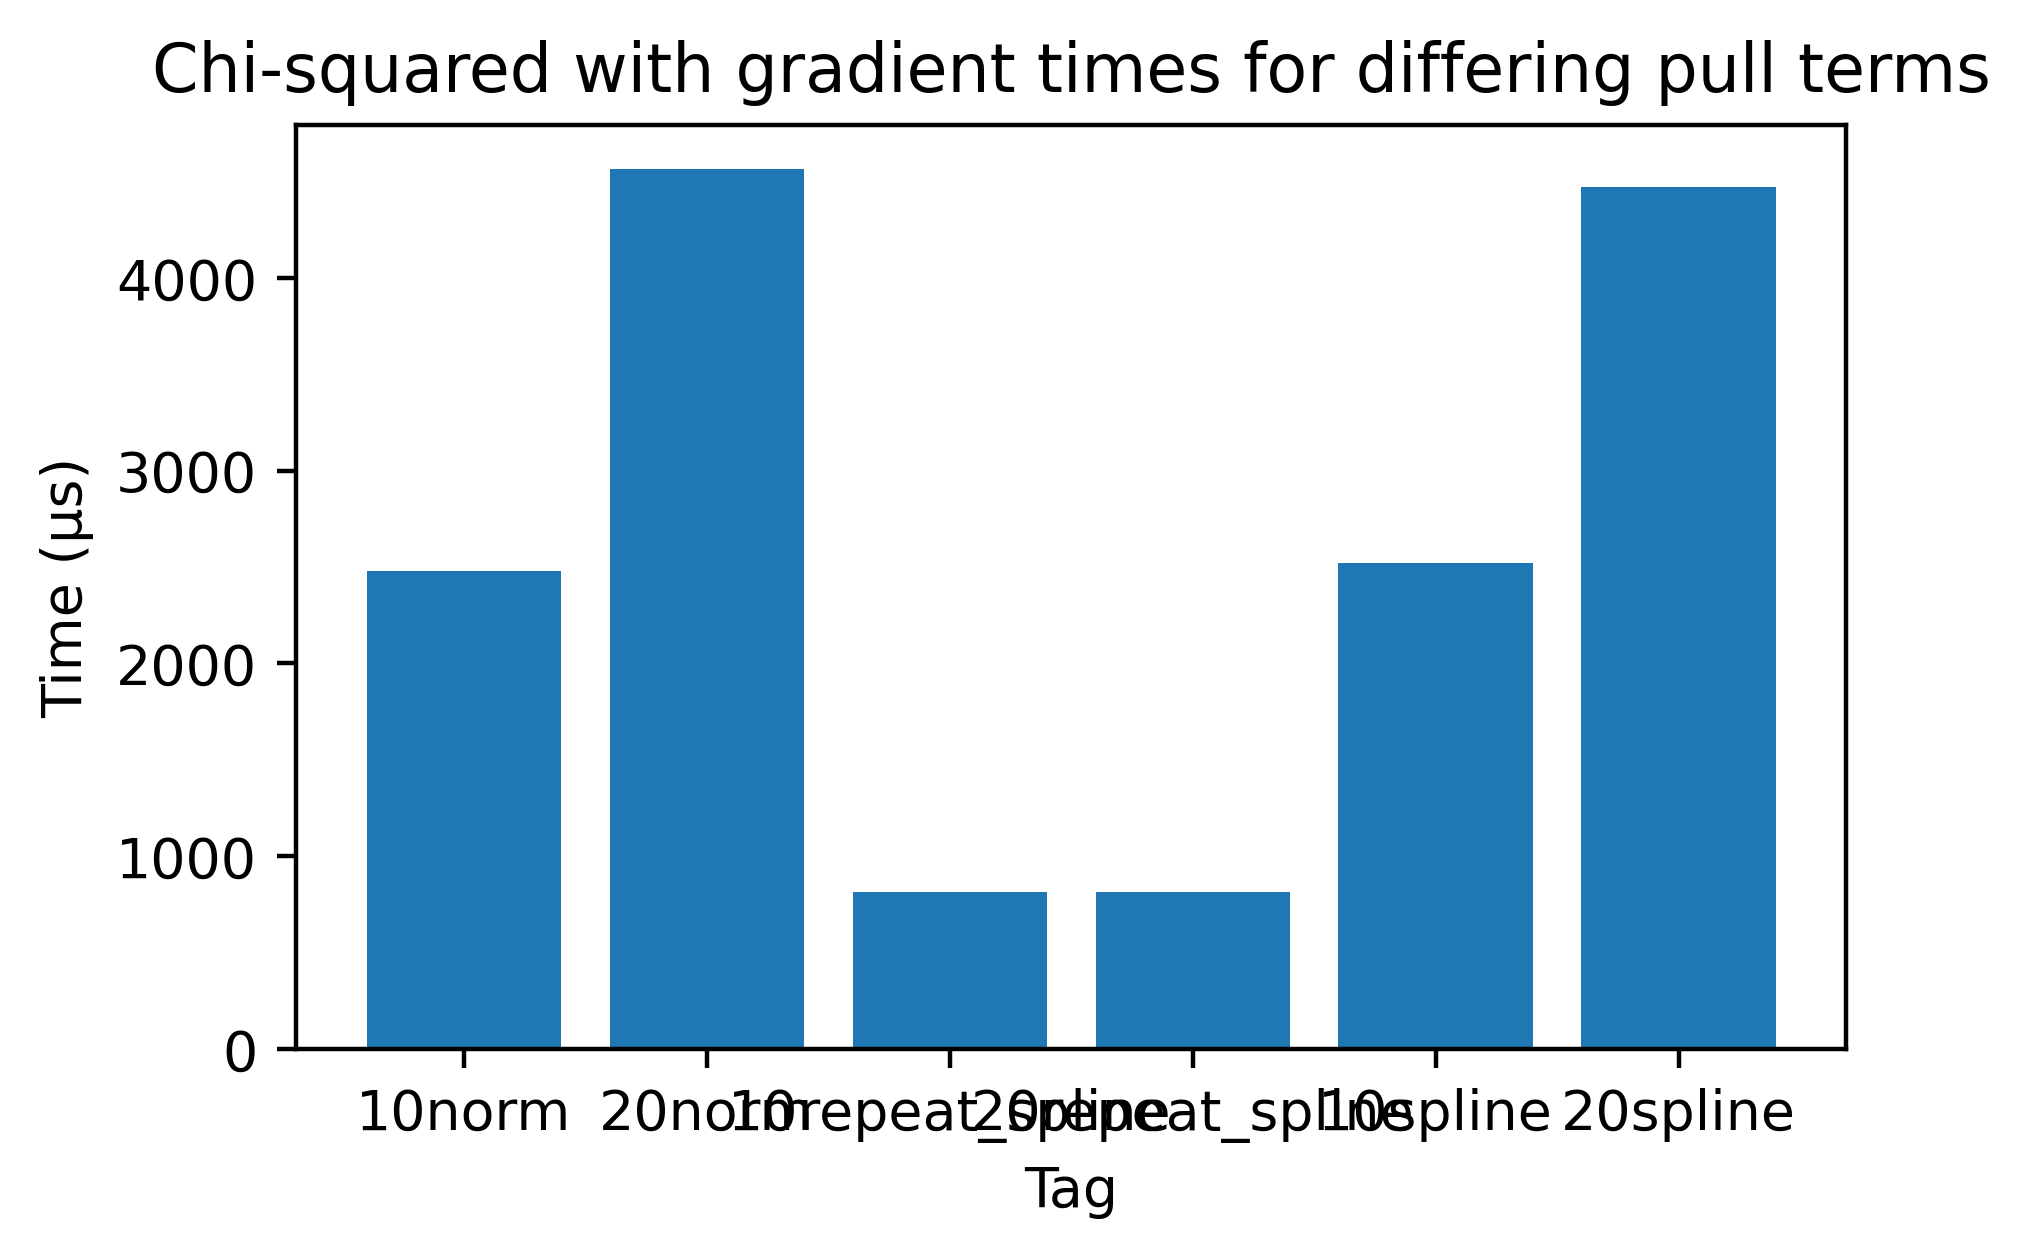

In [151]:
plt.figure(figsize=(5, 3), dpi=400)
plt.bar([t[9:] for t in tags], pulltest_chi2_with_grad_times)
plt.xlabel('Tag')
plt.ylabel('Time (μs)')
plt.title('Chi-squared with gradient times for differing pull terms')
plt.ylim(0,)
plt.show()

Issues: 

```
1 main || Default-CV collapsed bin 1230 has 0 expected events (<=0). Empty-bin would make CNP/stat covariance singular.
1 main || 4 collapsed CV bins are empty. Aborting. Re-run with --force to override (NOT recommended).
```